In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# 过滤掉warnings
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm/examples/logs/1gpu'
BASELINE_DATA_PATH = '/root/workspace/vllm-spec/vllm/examples/logs/1gpu'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

In [2]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_itl, p99_itl = [], [], [], [], [], []
    for store_cache_layer in store_cache_layers:
        if baseline_policy == 'full_mem':
            filename = f'{DATA_PATH}/test_{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_{store_cache_layer}.log'
        else:    
            filename = f'{DATA_PATH}/test_{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_swap_{store_cache_layer}.log'
        with open(filename, 'r') as f:
            lines = f.readlines()
            output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_itl_, p99_itl_ = [], [], [], [], [], []
            for line in lines:
                if 'Output token throughput' in line:
                    output_tokens_tgt.append(float(line.split()[-1]))
                if 'Request throughput' in line:
                    reqs_tgt.append(float(line.split()[-1]))
                if 'Mean TPOT' in line:
                    mean_tpot_.append(float(line.split()[-1]))
                if 'P99 TPOT' in line:
                    p99_tpot_.append(float(line.split()[-1]))
                if 'Mean ITL' in line:
                    mean_itl_.append(float(line.split()[-1]))
                if 'P99 ITL' in line:
                    p99_itl_.append(float(line.split()[-1]))    

        output_tokens.append(np.mean(output_tokens_tgt))
        reqs.append(np.mean(reqs_tgt))
        mean_tpot.append(np.mean(mean_tpot_))
        p99_tpot.append(np.mean(p99_tpot_))
        mean_itl.append(np.mean(mean_itl_))
        p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_itl, p99_itl            

In [3]:
def get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy):
    if baseline_policy == 'full_mem':
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_1.0_1gpu.log'
    else:    
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_{baseline_policy}_1.0_1gpu.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_itl, p99_itl = [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean ITL' in line:
                mean_itl.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl.append(float(line.split()[-1]))    
        
    return np.mean(output_tokens_tgt), np.mean(reqs_tgt), np.mean(mean_tpot_), np.mean(p99_tpot_), np.mean(mean_itl), np.mean(p99_itl)         

In [4]:
# plot throughput
def plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_itl, baseline_p99_itl = get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [abs(mean_tpot[i]-baseline_mean_tpot) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [abs(p99_tpot[i]-baseline_p99_tpot) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_itl_imp = [abs(mean_itl[i]-baseline_mean_itl) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [abs(p99_itl[i]-baseline_p99_itl) / baseline_p99_itl *100 for i in range(len(p99_itl))]
    
    # print(f'reqs_imp: max:{float(max(reqs_imp)):.2f}%, mean:{float(np.mean(reqs_imp)):.2f}%, min:{float(min(reqs_imp)):.2f}%')
    # print(f'output_tokens_imp: max:{float(max(output_tokens_imp)):.2f}%, mean:{float(np.mean(output_tokens_imp)):.2f}%, min:{float(min(output_tokens_imp)):.2f}%')
    # print(f'mean_tpot_imp: max:{float(max(mean_tpot_imp)):.2f}%, mean:{float(np.mean(mean_tpot_imp)):.2f}%, min:{float(min(mean_tpot_imp)):.2f}%')
    # print(f'p99_tpot_imp: max:{float(max(p99_tpot_imp)):.2f}%, mean:{float(np.mean(p99_tpot_imp)):.2f}%, min:{float(min(p99_tpot_imp)):.2f}%')
    # print(f'mean_itl_imp: max:{float(max(mean_itl_imp)):.2f}%, mean:{float(np.mean(mean_itl_imp)):.2f}%, min:{float(min(mean_itl_imp)):.2f}%')
    # print(f'p99_itl_imp: max:{float(max(p99_itl_imp)):.2f}%, mean:{float(np.mean(p99_itl_imp)):.2f}%, min:{float(min(p99_itl_imp)):.2f}%')

    # fig = plt.figure(figsize=(3, 2), dpi=120)
    # ax = fig.add_subplot(111)
    # ax.plot(store_cache_layers, output_tokens_imp, label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/5), markersize=3)
    # ax.plot(store_cache_layers, reqs_imp, label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.DDark2(1/5), markersize=3)
    # ax.plot(store_cache_layers, mean_tpot_imp, label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/5), markersize=3)
    # ax.plot(store_cache_layers, p99_tpot_imp, label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/5), markersize=3)
    # ax.plot(store_cache_layers, mean_itl_imp, label='avg_itl', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/5), markersize=3)
    # ax.plot(store_cache_layers, p99_itl_imp, label='p99_itl', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/5), markersize=3)
    # ax.set_xlabel('Store cache layers(%)')
    # ax.set_ylabel('Improvement(%)')
    # ax.spines['right'].set_visible(False)
    # ax.spines['top'].set_visible(False)
    # ax.grid(linestyle='-.', alpha=0.3)
    # ax.set_ylim(min(min(output_tokens_imp), min(reqs_imp), min(mean_tpot_imp), min(p99_tpot_imp), min(mean_itl_imp), min(p99_itl_imp))*1.4, max(max(output_tokens_imp), max(reqs_imp), max(mean_tpot_imp), max(p99_tpot_imp), max(mean_itl_imp), max(p99_itl_imp))*1.4)
    # ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    # ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    # # x轴标签显示数字乘以100
    # ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
    # ax.legend( bbox_to_anchor=(-0.04, 1.05), loc='upper left', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5) 
    # name = model_name.split('_')[-1]
    # plt.title(f'{name}_reqs_{req_rate}_total_{total_reqs}')
    # plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    # plt.show()

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_itl_imp, p99_itl_imp
    

In [5]:
# 绘制一张大图，将不同req_rate的结果放在一张图上, 6个指标, 这张大图包含6个子图，legend放在右上角
def plot_big_fig(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(15, 2), dpi=120)
    axes = [fig.add_subplot(1, 6, i+1) for i in range(6)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
        ax.plot(store_cache_layers, mean_mean_tpot_imps[i], label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
        ax.plot(store_cache_layers, mean_mean_itl_imps[i], label='avg_itl', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='p99_itl', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
        ax.set_xlabel('Cache layers(%)')
        if i == 0 : ax.set_ylabel('Improvement(%)')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        # 除了第一个子图，其他子图的y轴不显示
        # if i != 0: ax.set_yticklabels([])
        ax.set_ylim(min(min(mean_output_tokens_imps[i]), min(mean_reqs_imps[i]), min(mean_mean_tpot_imps[i]), min(mean_p99_tpot_imps[i]), min(mean_mean_itl_imps[i]), min(mean_p99_itl_imps[i]))*1.4, max(max(mean_output_tokens_imps[i]), max(mean_reqs_imps[i]), max(mean_mean_tpot_imps[i]), max(mean_p99_tpot_imps[i]), max(mean_mean_itl_imps[i]), max(mean_p99_itl_imps[i]))*1.4)
        # ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        # ax.yaxis.set_major_locator(plt.MultipleLocator(20))
        # ax.set_ylim(-10, 80)
        # x轴标签显示数字乘以100
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        name = model_name.split('_')[-1]
        ax.set_title(f'{req_rates[i]} reqs/s')
    # legend 放在右上角
    axes[-1].legend( bbox_to_anchor=(1.4, 1.0), loc='upper right', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()

In [6]:
def plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.plot(req_rates, mean_output_tokens_imps, label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
    ax.plot(req_rates, mean_reqs_imps, label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
    ax.plot(req_rates, mean_mean_tpot_imps, label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/6), markersize=5)
    ax.plot(req_rates, mean_p99_tpot_imps, label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
    ax.plot(req_rates, mean_mean_itl_imps, label='avg_itl', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/6), markersize=5)
    ax.plot(req_rates, mean_p99_itl_imps, label='p99_itl', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5, markerfacecolor='none')
    ax.set_xlabel('Req rates(reqs/s)')
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='-.', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))
    # if baseline_policy == 'full_mem': ax.yaxis.set_major_locator(plt.MultipleLocator(40))
    # else: ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.set_ylim(min(min(mean_output_tokens_imps), min(mean_reqs_imps), min(mean_mean_tpot_imps), min(mean_p99_tpot_imps), min(mean_mean_itl_imps), min(mean_p99_itl_imps))*1.2, max(max(mean_output_tokens_imps), max(mean_reqs_imps), max(mean_mean_tpot_imps), max(mean_p99_tpot_imps), max(mean_mean_itl_imps), max(mean_p99_itl_imps))*1.4)
    ax.legend( bbox_to_anchor=(-0.04, 1.1), loc='upper left', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()

In [7]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(swap_imps, recompute_imps):
    # print(f'swap_imps: {swap_imps}, recompute_imps: {recompute_imps}')
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.4
    bar1 = ax.bar(np.arange(6), swap_imps, bar_width, label='swap', color='skyblue', hatch=hatches[0])
    bar2 = ax.bar(np.arange(6)+bar_width, recompute_imps, bar_width, label='recompute', color='orange', hatch=hatches[1])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(6), swap_imps):
        ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=45, fontsize=6)
    for x, y in zip(np.arange(6)+0.4, recompute_imps):
        ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=45, fontsize=6)
    ax.set_xticks(np.arange(6)+0.2)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_itl', 'p99_itl'], rotation=45)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.set_ylim(min(min(swap_imps), min(recompute_imps)), max(max(swap_imps), max(recompute_imps))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.legend( bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

In [12]:
def plot_all_figs(model_name, gpu_utilization):
    model_name = model_name.replace('/', '_')
    req_rates = [50, 100, 150, 200, 250, 300]
    total_reqs = 300
    store_cache_layers = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    baseline_policies = ['swap', 'recompute', 'full_mem']
    swap_imps, recompute_imps = [], []
    for baseline_policy in baseline_policies:
        print(f'baseline_policy---------------------->: {baseline_policy}')
        mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps = [], [], [], [], [], []
        output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_itl_imps_all, p99_itl_imps_all = [], [], [], [], [], []
        for req_rate in req_rates:
            output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_itl_imps, p99_itl_imps = plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
            mean_output_tokens_imps.append(np.max(output_tokens_imps))
            mean_reqs_imps.append(np.max(reqs_imps))
            mean_mean_tpot_imps.append(np.max(mean_tpot_imps))
            mean_p99_tpot_imps.append(np.max(p99_tpot_imps))
            mean_mean_itl_imps.append(np.max(mean_itl_imps))
            mean_p99_itl_imps.append(np.max(p99_itl_imps))

            output_tokens_imps_all.append(output_tokens_imps)
            reqs_imps_all.append(reqs_imps)
            mean_tpot_imps_all.append(mean_tpot_imps)
            p99_tpot_imps_all.append(p99_tpot_imps)
            mean_itl_imps_all.append(mean_itl_imps)
            p99_itl_imps_all.append(p99_itl_imps)

        plot_big_fig(baseline_policy, req_rates, store_cache_layers, output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_itl_imps_all, p99_itl_imps_all)
        plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_itl_imps, mean_p99_itl_imps)
            
        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')  
        print(f'mean_p99_tpot_imps: {mean_p99_tpot_imps}')
        base_imps = []
        base_imps.append(np.mean(mean_output_tokens_imps))
        base_imps.append(np.mean(mean_reqs_imps))
        base_imps.append(np.mean(mean_mean_tpot_imps))
        base_imps.append(np.mean(mean_p99_tpot_imps))
        base_imps.append(np.mean(mean_mean_itl_imps))
        base_imps.append(np.mean(mean_p99_itl_imps))
        if baseline_policy == 'swap':
            swap_imps = base_imps
        if baseline_policy == 'recompute':
            recompute_imps = base_imps 

    plot_bar(swap_imps, recompute_imps)        

baseline_policy---------------------->: swap
mean_output_tokens_imps: [[-10.487063524163224, -16.323874569499104, -13.881126594845036, 13.271377970609482, 8.527441752154019, 4.407042443406724, -0.46665686166368003, 1.7157223223149332, 2.276905541052301], [7.169100993527492, -21.61920484248175, -11.389495653107574, 21.60226018273393, 8.510413416144102, 3.2097547554097385, 3.5603917739549, 2.4254351086639594, 1.7702975213821703], [17.82530792353472, -15.26964232129506, -13.028621581445995, 33.975574261564624, 2.3783960050162967, 14.474184030819263, 7.639244227897265, 8.492636026663309, 4.667983757803251], [-1.4652716458690955, -25.336121153557812, -16.880195924895464, 23.130300051646874, 8.39344917781517, 6.416706929010544, 4.7348516402046, 1.5793945654165933, -2.6689768921913237], [7.324377912329232, -23.559838116531445, -18.037753941789184, 23.234706057644793, 6.7949770176750235, 8.661198410465504, 6.669285924761838, -1.0594677023834371, 0.5994882458018532], [22.584735528540385, -19.61

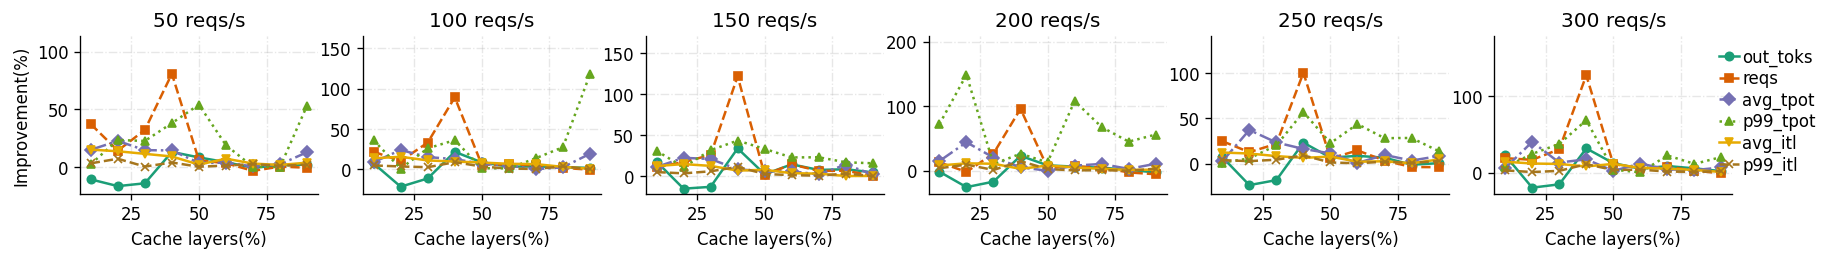

mean_output_tokens_imps: [13.271377970609482, 21.60226018273393, 33.975574261564624, 23.130300051646874, 23.234706057644793, 31.65287953197542]


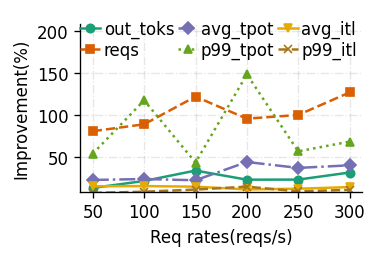

mean_output_tokens_imps: 24.47784967602919, mean_reqs_imps: 102.59096300182715, mean_mean_tpot_imps: 31.796541261107603, mean_p99_tpot_imps: 81.58565778877148, mean_mean_itl_imps: 13.954864451726815, mean_p99_itl_imps: 10.41851538170595
mean_p99_tpot_imps: [54.165564765351704, 117.72447608697514, 43.53180379381254, 148.69015635775972, 56.942436327237466, 68.4595094014924]
baseline_policy---------------------->: recompute
mean_output_tokens_imps: [[-9.197365294438441, -15.118272842121105, -12.640329868145061, 14.903386721507925, 10.091100090433379, 5.911334259890822, 0.9674149216785378, 3.181237723540531, 3.7505064440193387], [9.121564487446904, -20.19122196541467, -9.775142511099375, 23.817674622006095, 10.487313650829472, 5.090084780651655, 5.447109890278849, 4.29147598280133, 3.624402751655743], [18.188983364912325, -15.008116586544737, -12.760178791089674, 34.38909854562601, 2.6943935526638563, 14.827516011337122, 7.971479724192652, 8.827505571997515, 4.99104826628666], [2.321739055

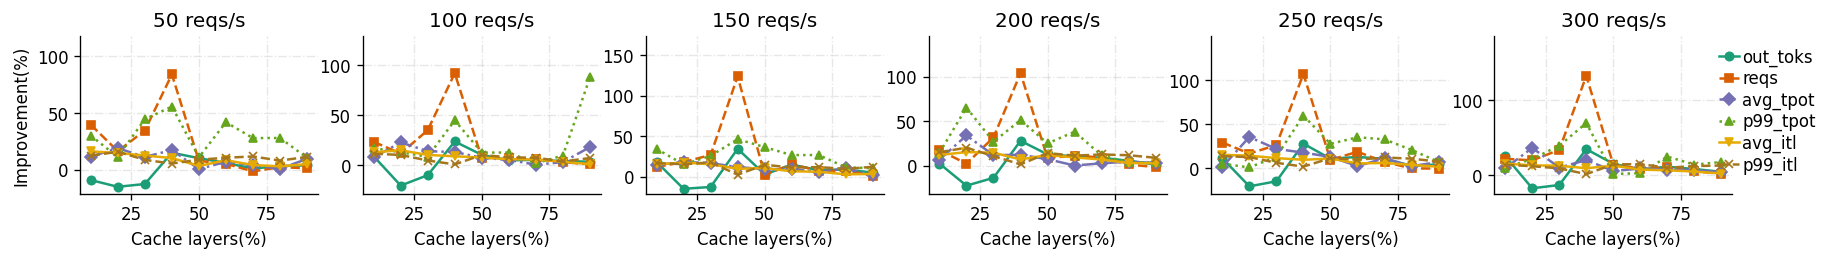

mean_output_tokens_imps: [14.903386721507925, 23.817674622006095, 34.38909854562601, 27.862598721486503, 27.631529036907793, 34.431667934041684]


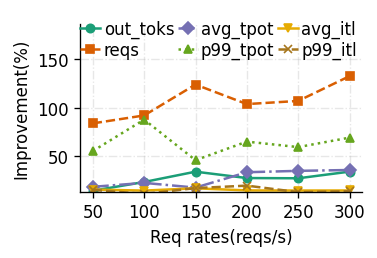

mean_output_tokens_imps: 27.172659263596003, mean_reqs_imps: 107.05243881080982, mean_mean_tpot_imps: 27.506271454724384, mean_p99_tpot_imps: 63.909086558646095, mean_mean_itl_imps: 15.637597407178562, mean_p99_itl_imps: 15.477006645427915
mean_p99_tpot_imps: [55.53442987569729, 87.72503246369968, 46.1753046542358, 65.17512254818176, 59.57305566536634, 69.2715741446957]
baseline_policy---------------------->: full_mem
mean_output_tokens_imps: [[7.435171664232887, 12.993672194328306, 2.7551625959339185, 19.228127729657995, 4.235429043894551, -7.595033772745763, 5.774872810439198, -5.830549498909818, -10.017969901248906], [8.897993414494977, 7.06773171284998, 3.395178420441183, -6.316379209601918, 6.155178695410087, 12.46399626042303, 9.807968598552293, 2.3597486784307518, 2.319362622103371], [11.275561515253099, 10.055313442842778, -1.5437479047938378, -0.5154207173985996, -0.10895072075091808, 15.703989272544408, 5.841434797184046, -13.52748910492793, -2.262822661749916], [-8.864138782

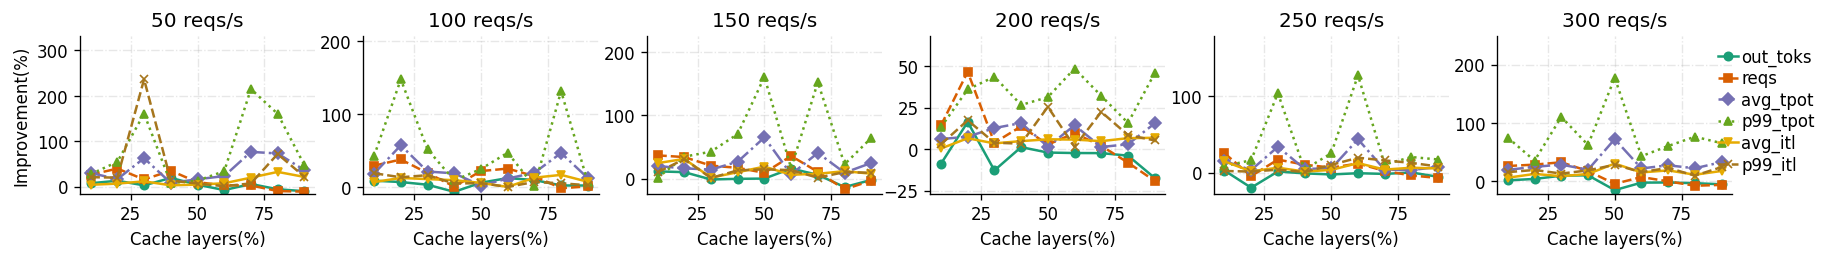

mean_output_tokens_imps: [19.228127729657995, 12.46399626042303, 15.703989272544408, 16.29225237323682, 2.956693160807183, 10.217016537864852]


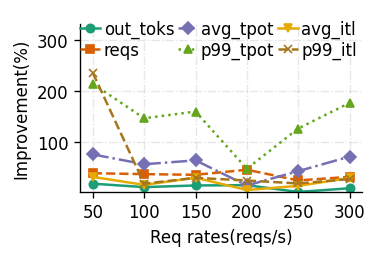

mean_output_tokens_imps: 12.810345889089048, mean_reqs_imps: 36.48769170147043, mean_mean_tpot_imps: 55.07766888897854, mean_p99_tpot_imps: 146.0270987985947, mean_mean_itl_imps: 22.055905555206547, mean_p99_itl_imps: 59.95168220504018
mean_p99_tpot_imps: [215.00847936687387, 147.3651324885, 160.51376172014625, 48.45641388117751, 127.32072602640538, 177.4980793084652]


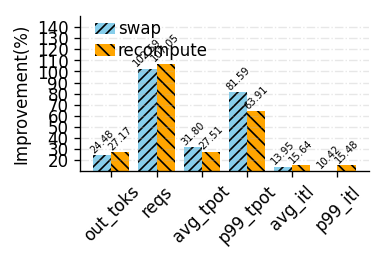

In [13]:
model_name = 'facebook/opt-2.7b'
gpu_utilization = 0.1
plot_all_figs(model_name, gpu_utilization)

baseline_policy---------------------->: swap
mean_output_tokens_imps: [[5.514520794980646, -1.1612878987113444, -3.871961528346548, -8.778224443025145, -0.06462035541196007, -0.2043806589773388, -0.55265431866853, -0.9200886651388299, 6.05327422324079], [6.812854465726989, 3.8221223722377204, -2.0584524420639907, -9.312050443140139, 1.4262896831532583, -0.5961363622307176, 5.238052533598873, -3.7770507214556472, 8.313438928299743], [6.2594390671908835, -0.3716011715143405, -0.9723385652006376, -8.910326568795893, 4.246280931097107, 4.8928761410953445, 3.5859283762053016, 0.6579068046885123, 10.634274743349096], [2.7102167068657623, 2.376502863034638, 1.3638539576160509, -5.6234234897722395, 6.31662769502698, 2.272936497707739, 1.3201259367002485, -1.9939977537606073, 2.1670686575957996], [4.200688506974603, 0.8228255318019894, -1.5103375541419906, -9.459342933517295, 0.8321117530395689, 0.8947937463932967, 2.1739707218710373, 0.9714050716033937, 8.948269114691461], [3.9643153122410264,

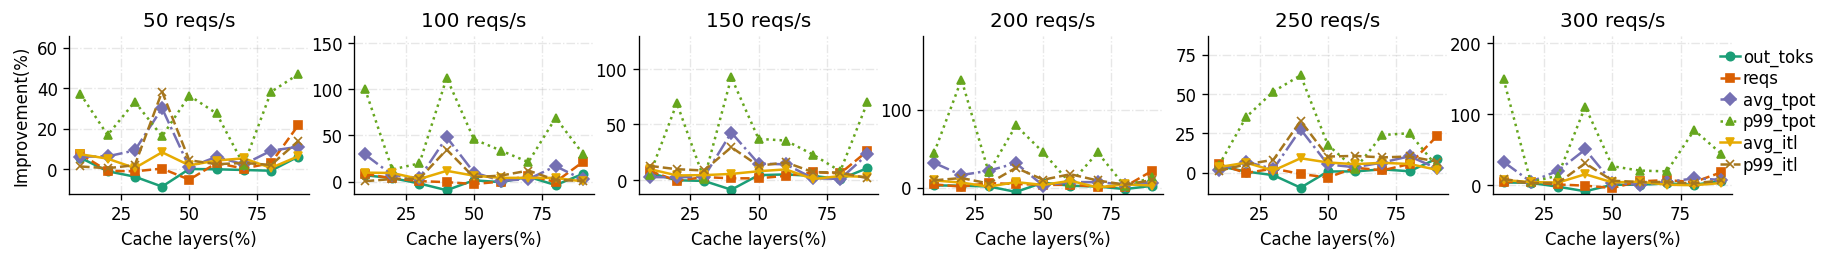

mean_output_tokens_imps: [6.05327422324079, 8.313438928299743, 10.634274743349096, 6.31662769502698, 8.948269114691461, 5.973122735176072]


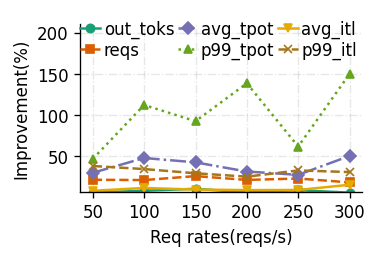

mean_output_tokens_imps: 7.706501239964023, mean_reqs_imps: 21.95448576378664, mean_mean_tpot_imps: 38.36927092959396, mean_p99_tpot_imps: 100.29785442788445, mean_mean_itl_imps: 10.572987169171641, mean_p99_itl_imps: 31.89986660951857
mean_p99_tpot_imps: [46.920668058455114, 112.16426884344361, 92.5460877966683, 138.49461674728542, 61.8563519077018, 149.8051332137524]
baseline_policy---------------------->: recompute
mean_output_tokens_imps: [[11.682329212503742, 4.61628883558464, 1.7471638809179988, -3.44589263786116, 5.777061634291752, 5.629131698999182, 5.260499844116841, 4.8715872722992435, 12.252575253389677], [9.059306059429192, 6.005673906659971, 0.0014208447395524827, -7.404732360212559, 3.559452880052288, 1.4944918585596507, 7.451383429161419, -1.7533224086160017, 10.591450303587159], [10.731199135998923, 3.8211020792415047, 3.195083604528349, -5.076962042253869, 8.633320430662469, 9.307126575201066, 7.945177985176254, 4.893935266822448, 15.290142837345098], [6.19949170450326

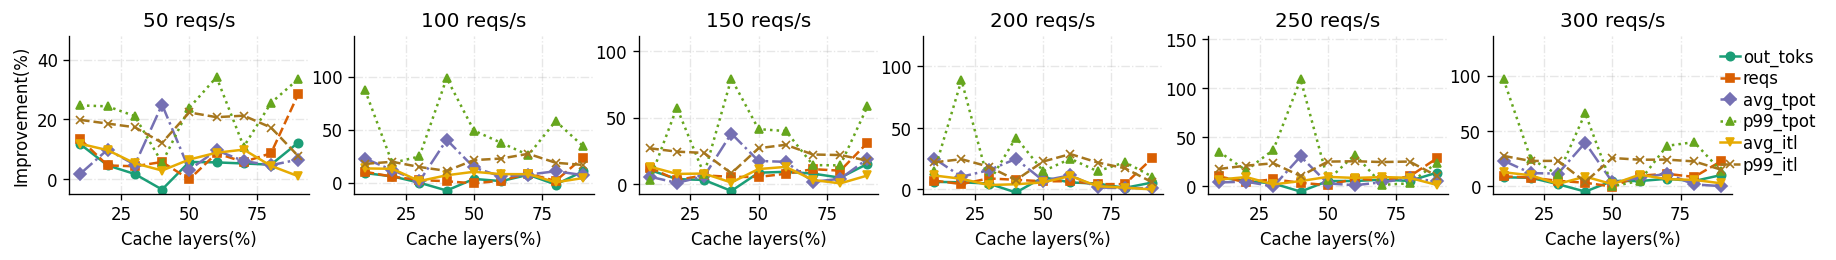

mean_output_tokens_imps: [12.252575253389677, 10.591450303587159, 15.290142837345098, 9.92841981019827, 13.992217369548648, 10.297460441739156]


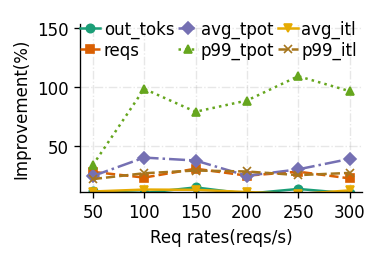

mean_output_tokens_imps: 12.058711002634668, mean_reqs_imps: 26.65673554485669, mean_mean_tpot_imps: 33.10327017569985, mean_p99_tpot_imps: 84.51554282677489, mean_mean_itl_imps: 12.063576853288026, mean_p99_itl_imps: 26.86648653578936
mean_p99_tpot_imps: [34.105168418977776, 98.7114111194673, 79.29021773040897, 88.79285916690279, 109.40369273995283, 96.78990778493973]
baseline_policy---------------------->: full_mem
mean_output_tokens_imps: [[14.572842564582347, 12.088001039115536, 5.743184098520205, -3.0911805067947333, -1.0345976533307193, -2.600800796655258, -13.060665899879718, 0.35277219838824586, -4.622558219648694], [4.601848218054173, -8.07873438529719, -1.7504757532451214, -5.7425452983731855, 1.8269294848536506, 1.4918659153344285, -6.499677894690084, -1.2534339387925997, -14.525468533643346], [2.128884037252051, 10.073490118342393, 10.381335610963683, -9.225773153497965, -7.22249373118785, -3.3264669477165048, -2.9035219534029584, -2.1078738107526522, 1.8365678424781122], [

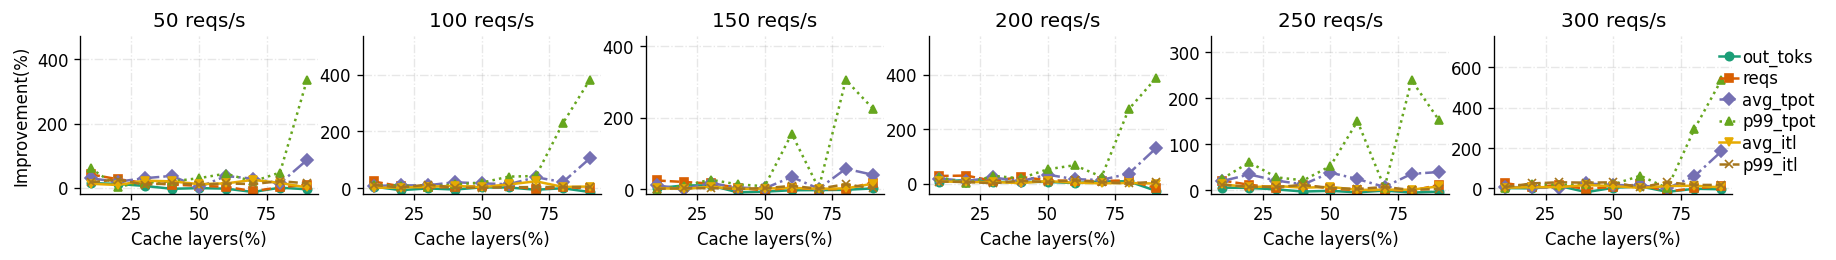

mean_output_tokens_imps: [14.572842564582347, 4.601848218054173, 10.381335610963683, 13.156367647411454, 5.069161755473186, 11.91697874336091]


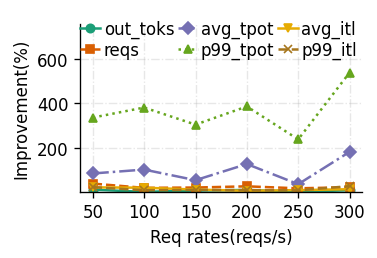

mean_output_tokens_imps: 9.94975575664096, mean_reqs_imps: 27.266838359595685, mean_mean_tpot_imps: 99.97559334274331, mean_p99_tpot_imps: 364.7936483154813, mean_mean_itl_imps: 16.845913753564755, mean_p99_itl_imps: 17.530520302973894
mean_p99_tpot_imps: [336.9818097872656, 381.8924471551362, 305.49375709421105, 386.72279454060555, 239.4511086386854, 538.2199726769836]


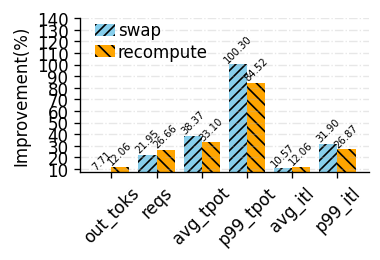

In [10]:
model_name = 'meta-llama/Llama-2-7b-hf'
gpu_utilization = 0.2
plot_all_figs(model_name, gpu_utilization)


baseline_policy---------------------->: swap
mean_output_tokens_imps: [[9.245381167258605, 7.214413894205503, 8.457634669806021, 6.451556701569751, 8.906886621749752, 2.6609155779669846, 3.712488706477924, 2.4705123961182607, 2.918519882821138], [5.046296526888823, 3.809813170228768, 8.842910579715193, 8.966185355454718, 4.474749839369221, 6.168221506094, 4.6117218124131405, 2.66796499494448, 0.2771814654506733], [3.1243815493144846, 8.232314502371114, 8.435228955140897, 3.7456504911281434, 5.829907586244918, 4.8679427731141045, 3.85337050926519, 6.0090234303565095, 2.9891052474679722], [4.2169406781132235, 7.217880641953128, 8.038798929582065, 10.174178523686335, 6.921506819078031, 4.848130116788632, 6.165071538936562, 5.7806536096843395, 2.63462687899762], [6.616133728226499, 8.808543747803833, 10.175192008433331, 9.292957180864423, 6.618643642387447, 6.882184629285683, 6.899754028412246, 6.721550122985802, 3.8753074644847283], [4.494199622881818, 2.748467176983303, 7.283875076485049

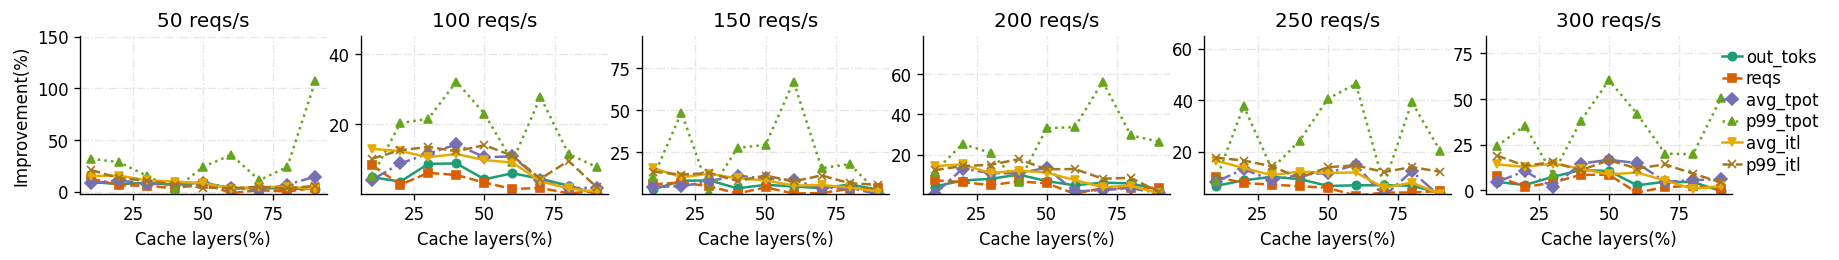

mean_output_tokens_imps: [9.245381167258605, 8.966185355454718, 8.435228955140897, 10.174178523686335, 10.175192008433331, 10.975137673105978]


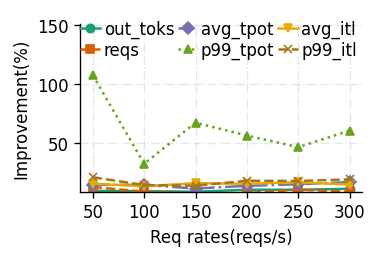

mean_output_tokens_imps: 9.661883947179978, mean_reqs_imps: 9.015144486556752, mean_mean_tpot_imps: 14.15216744044035, mean_p99_tpot_imps: 61.54577302512289, mean_mean_itl_imps: 15.063974309230147, mean_p99_itl_imps: 17.15088949791473
mean_p99_tpot_imps: [107.36516563502194, 32.14093992484505, 67.05377343071218, 56.129121186798415, 46.316878909238184, 60.26875906412158]
baseline_policy---------------------->: recompute
mean_output_tokens_imps: [[14.412434768555462, 12.285407445638299, 13.58742968558575, 11.486468873978854, 14.057930214735931, 7.5165392014263785, 8.617849304284823, 7.317130389902898, 7.786327593487553], [11.660701616916736, 10.3463611431718, 15.696375438113503, 15.827412403773877, 11.05316659430956, 12.85327036499752, 11.19876322282109, 9.13261470367116, 6.591291733288155], [7.072443713845779, 12.375931166507158, 12.58661409130636, 7.717497607058152, 9.881549377835128, 8.882756252861144, 7.829341628865137, 10.067522576886269, 6.931988430646322], [9.934124812289735, 13.0

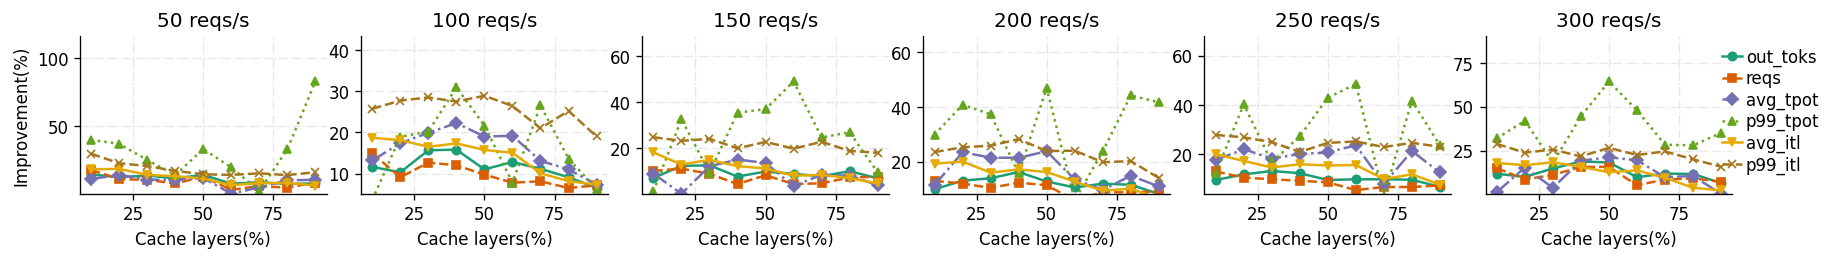

mean_output_tokens_imps: [14.412434768555462, 15.827412403773877, 12.58661409130636, 16.218167738424754, 13.194118526846744, 18.74919827254458]


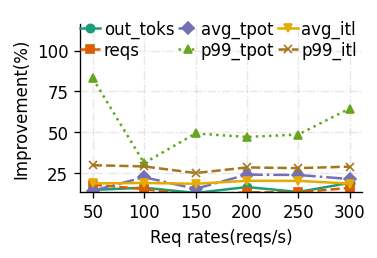

mean_output_tokens_imps: 15.164657633575295, mean_reqs_imps: 14.243489470641896, mean_mean_tpot_imps: 19.986265855446863, mean_p99_tpot_imps: 53.784254185188196, mean_mean_itl_imps: 18.96320527402709, mean_p99_itl_imps: 28.02126082337173
mean_p99_tpot_imps: [82.87728160353757, 30.911981715648512, 49.09977350378136, 46.97808015191568, 48.456874576954654, 64.38153355929146]
baseline_policy---------------------->: full_mem
mean_output_tokens_imps: [[8.589077126504268, -5.23516972413562, 9.98295836973178, 11.67757426475151, 6.227355396754932, 6.233322354131757, 8.791953677316496, 6.389656637404712, -1.4533121387007306], [11.599814955276942, 8.049210624572902, 14.875670141343168, 5.1009409571132975, 6.2727343175771315, 7.280147847915782, 0.816498099064673, -1.4625108314566655, -0.951759216424832], [14.065927715021212, 9.143864397637227, 20.897578219629025, 0.8216281819429713, 3.003325523210042, 5.791852588538148, -5.914904171472739, 0.9167463331350743, -6.79143599511646], [17.17208076830778

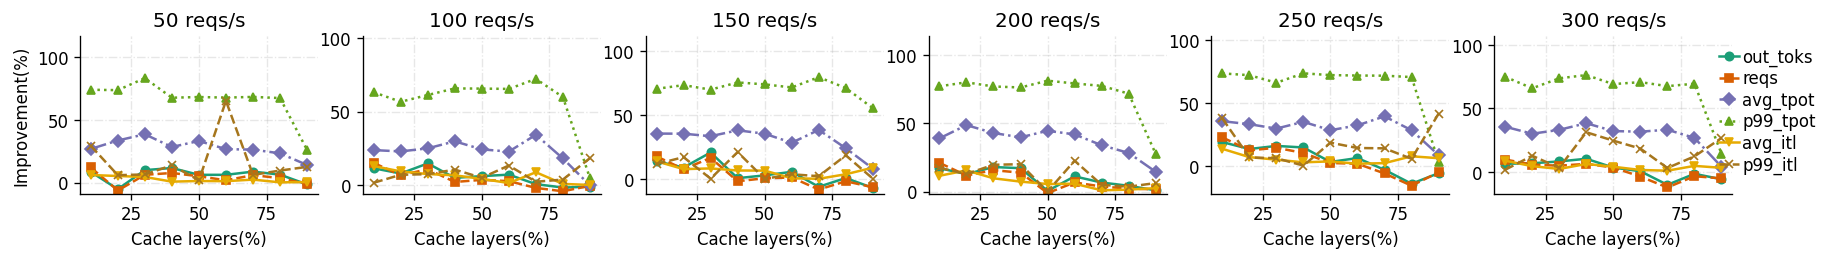

mean_output_tokens_imps: [11.67757426475151, 14.875670141343168, 20.897578219629025, 18.026681163040116, 18.873593924740415, 10.385013469279999]


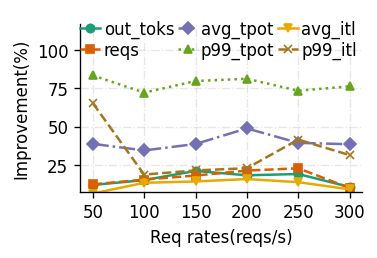

mean_output_tokens_imps: 15.789351863797371, mean_reqs_imps: 16.44750885952978, mean_mean_tpot_imps: 39.662291719035856, mean_p99_tpot_imps: 77.78039190077375, mean_mean_itl_imps: 11.855210440495147, mean_p99_itl_imps: 33.40518224485945
mean_p99_tpot_imps: [83.50131043446763, 72.23032298479811, 79.80579464167121, 81.34841899775328, 73.45907937812906, 76.33742496782325]


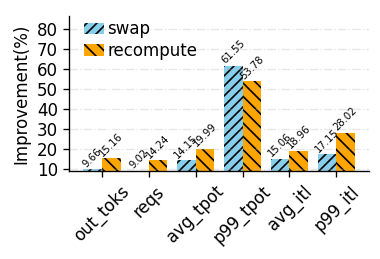

In [11]:
model_name = 'meta-llama/Llama-2-13b-hf'
gpu_utilization = 0.4
plot_all_figs(model_name, gpu_utilization)